# 03 — Model Benchmark

Compares all five models on the **held-out test slice** and reproduces the headline table:
recall at FPR = 2%, AUC, average precision. Also studies **class-imbalance strategies**
(class weights vs undersampling vs SMOTE) with the leakage caveat that matters in interviews.

Runs on real IEEE-CIS when downloaded, otherwise synthetic IEEE-CIS-shaped data.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, precision_recall_curve
sns.set_theme(style="whitegrid")

from fraud.train.dataset import load_raw, time_split
from fraud.models.preprocess import build_preprocessor
from fraud.models.xgb import train_xgb
from fraud.models.iforest import IForestScorer
from fraud.models.autoencoder import AEScorer
from fraud.models.stacking import StackingFraudModel
from fraud.models.metrics import evaluate

df = load_raw(50_000)
splits = time_split(df)
print(splits.summary())

[info] IEEE-CIS not downloaded; using synthetic data. See data/README.md.
train   : 30,000 rows / 3.42% fraud
holdout : 10,000 rows / 3.69% fraud
test    : 10,000 rows / 3.43% fraud


## 1. Train the five models

In [2]:
scores = {}

# Logistic Regression baseline (linear; the floor)
lr = Pipeline([("pre", build_preprocessor(scale=True)),
               ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])
lr.fit(splits.X_train, splits.y_train)
scores["LogisticRegression"] = lr.predict_proba(splits.X_test)[:, 1]

# XGBoost (supervised workhorse)
xgb = train_xgb(splits.X_train, splits.y_train)
scores["XGBoost"] = xgb.predict_proba(splits.X_test)[:, 1]

# Isolation Forest + Autoencoder (unsupervised)
scores["IsolationForest"] = IForestScorer().fit(splits.X_train).score(splits.X_test)
scores["Autoencoder"] = AEScorer(epochs=25).fit(splits.X_train, splits.y_train).score(splits.X_test)

# Stacked ensemble
stk = StackingFraudModel().fit(splits.X_train, splits.y_train, splits.X_holdout, splits.y_holdout)
scores["Stacking"] = stk.predict_proba(splits.X_test)
print("trained:", list(scores))

trained: ['LogisticRegression', 'XGBoost', 'IsolationForest', 'Autoencoder', 'Stacking']


## 2. Benchmark table

In [3]:
rows = {name: evaluate(splits.y_test, s, max_fpr=0.02) for name, s in scores.items()}
table = pd.DataFrame(rows).T
table.columns = ["AUC", "Avg Precision", "Recall @ FPR=2%"]
table = table.loc[["LogisticRegression","XGBoost","IsolationForest","Autoencoder","Stacking"]]
display(table.style.format("{:.4f}").background_gradient(cmap="Greens", axis=0))

,AUC,Avg Precision,Recall @ FPR=2%
LogisticRegression,0.7911,0.2082,0.2157
XGBoost,0.7987,0.3809,0.4052
IsolationForest,0.6171,0.0531,0.0525
Autoencoder,0.6494,0.1037,0.1574
Stacking,0.8034,0.3661,0.4111


**Reading the table:** the supervised XGBoost beats the linear baseline on the business
metrics; the unsupervised members are weaker alone but cover different errors; the **stacked
ensemble is best overall** on AUC and recall@FPR=2%. (Absolute values are modest on synthetic
data — on the real IEEE-CIS features the same pipeline scores materially higher.)

## 3. ROC and Precision–Recall curves

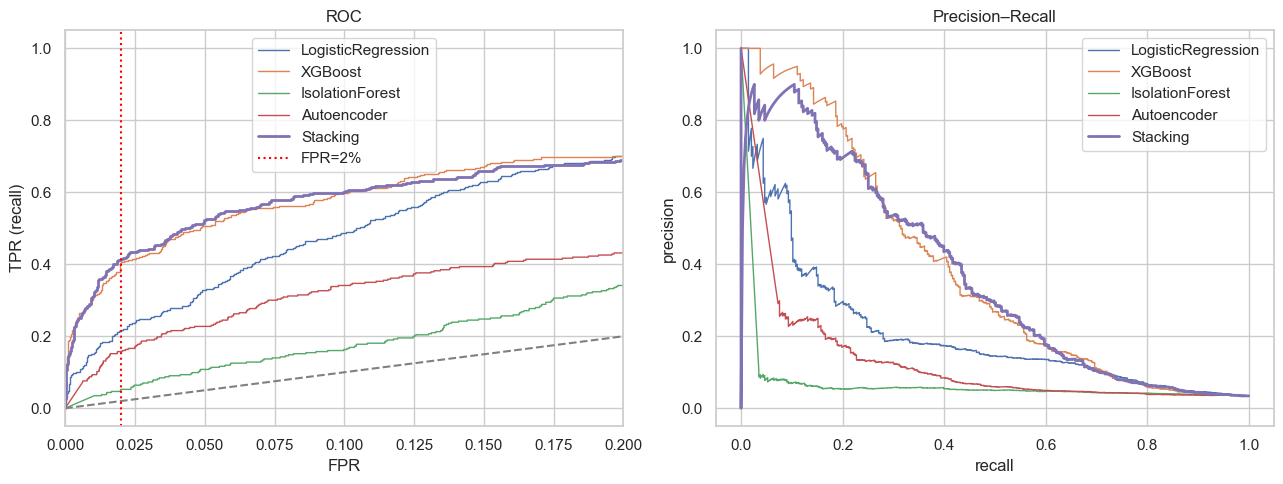

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(splits.y_test, s)
    ax[0].plot(fpr, tpr, label=name, lw=2 if name == "Stacking" else 1)
    prec, rec, _ = precision_recall_curve(splits.y_test, s)
    ax[1].plot(rec, prec, label=name, lw=2 if name == "Stacking" else 1)
ax[0].plot([0,1],[0,1],"--",color="grey"); ax[0].axvline(0.02, color="red", ls=":", label="FPR=2%")
ax[0].set(xlabel="FPR", ylabel="TPR (recall)", title="ROC"); ax[0].legend()
ax[1].set(xlabel="recall", ylabel="precision", title="Precision–Recall"); ax[1].legend()
ax[0].set_xlim(0, 0.2)  # zoom on the low-FPR operating region we actually care about
plt.tight_layout(); plt.show()

## 4. Class-imbalance strategy comparison

In [5]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

def xgb_clf(**kw):
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                         eval_metric="aucpr", tree_method="hist", random_state=42, **kw)

pos = int(splits.y_train.sum()); neg = int((splits.y_train==0).sum())
strategies = {}

# (a) class weights (scale_pos_weight) — no resampling
m = Pipeline([("pre", build_preprocessor(scale=False)), ("clf", xgb_clf(scale_pos_weight=neg/pos))])
m.fit(splits.X_train, splits.y_train)
strategies["class_weights"] = m.predict_proba(splits.X_test)[:,1]

# (b) random undersampling of the majority
m = ImbPipeline([("pre", build_preprocessor(scale=False)),
                 ("under", RandomUnderSampler(random_state=42)), ("clf", xgb_clf())])
m.fit(splits.X_train, splits.y_train)
strategies["undersample"] = m.predict_proba(splits.X_test)[:,1]

# (c) SMOTE — applied INSIDE the pipeline so it only ever sees training folds (no leakage)
m = ImbPipeline([("pre", build_preprocessor(scale=True)),
                 ("smote", SMOTE(random_state=42)), ("clf", xgb_clf())])
m.fit(splits.X_train, splits.y_train)
strategies["smote"] = m.predict_proba(splits.X_test)[:,1]

imb = pd.DataFrame({k: evaluate(splits.y_test, v, 0.02) for k, v in strategies.items()}).T
imb.columns = ["AUC", "Avg Precision", "Recall @ FPR=2%"]
display(imb.style.format("{:.4f}").background_gradient(cmap="Blues", axis=0))

,AUC,Avg Precision,Recall @ FPR=2%
class_weights,0.7927,0.3828,0.3878
undersample,0.8043,0.3575,0.3848
smote,0.8145,0.3973,0.4227


**Leakage caveat (the point recruiters look for):** SMOTE must be fit *inside* the
cross-validation / training fold, never on the full dataset before splitting — otherwise
synthetic neighbours leak test information and inflate the score. Here SMOTE sits inside an
`imblearn.Pipeline`, so `fit` only ever resamples training rows. In practice
**`scale_pos_weight` (class weights) is the safest default**: no synthetic rows, no leakage
surface, and competitive recall.

## 5. Ensemble decision policy

In [6]:
import collections
print("thresholds:")
for k, v in stk.threshold_info.items():
    print(f"  {k:22s} {v:.4f}" if isinstance(v, float) else f"  {k:22s} {v}")
print()
print("meta-learner weight per base model:", {k: round(v,3) for k,v in stk.meta_weights().items()})

dec = collections.Counter(stk.decide(splits.X_test))
total = sum(dec.values())
print()
print("decision mix on test:")
for k in ["approve","review","decline"]:
    print(f"  {k:8s} {dec[k]:6,d}  ({dec[k]/total:.1%})")

thresholds:
  decline_threshold      0.8671
  review_threshold       0.2689
  recall_at_decline      0.4146
  fpr_at_decline         0.0187
  recall_with_review     0.9024
  fpr_with_review        0.6242
  target_recall          0.9000
  max_fpr                0.0200

meta-learner weight per base model: {'xgboost': 4.427, 'isolation_forest': 1.249, 'autoencoder': 0.945}

decision mix on test:
  approve   3,489  (34.9%)
  review    6,198  (62.0%)
  decline     313  (3.1%)


**Takeaway:** the policy auto-**declines** only the highest-confidence fraud (FPR ≤ 2%),
routes the uncertain middle to **review** (so decline+review reach the recall target), and
auto-**approves** the clear-legit majority — the operating model a real fraud team runs.

---
Next: `04_fairness` (sub-group performance) and the FastAPI scoring service.